In [28]:
m_c6 = 3.895
samples_d = {
    '1' : 'Monini',
    '2' : 'Mill',
    '3' : 'GT EVOO',
    '4' : 'Sunflower oil',
    '5' : 'GT/Sunf 10/90',
    '6' : 'GT/Sunf 90/10',
    '7' : 'GT/Sunf 50/50',
    '8' : 'GAEA',
    '9' : 'Komili',
    '10': 'Taris',
    '11': 'Italian',
    'the_mill_100': 'Pure Mill',
    'the_mill_90_10': 'Mill 90/10',
    'the_mill_10_90': 'Mill 10/90',
    'the_mill_50_50': 'Mill 50/50',
    'gaea_1_99' : 'GAEA 1/99',
    'gaea_15_85' : 'GAEA 15/85',
    'gaea_50_50' : 'GAEA 50/50',
    'gaea_85_15' : 'GAEA 85/15',
}
dilutions_d = {
    '0' : 0.0,
    '1' : 0.3,
    '2' : 0.6,
    '3' : 0.9,
    '4' : 1.2,
    '5' : 1.5,
}
sample_mapper = {
    'monini' : '1',
    'mill' : '2',
    'groundtruth' : '3',
    'sunf' : '4',
    'gt_10' : '5',
    'gt_90' : '6',
    'gt_50' : '7',
    'gaeasitia' : '8',
    'komili' : '9',
    'taris' : '10',
    'italian' : '11',
    'gaea_1_99' : '12',
    'gaea_15_85' : '13',
    'gaea_50_50' : '14',
    'gaea_85_15' : '15',
    'gaea_1_99' : 'GAEA 1/99',
    'gaea_15_85' : 'GAEA 15/85',
    'gaea_50_50' : 'GAEA 50/50',
    'gaea_85_15' : 'GAEA 85/15',
}

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
data = []

In [32]:
folder_path = 'C:/Users/4spam/evoo/chem_samples/chem_samples_02'

for filename in os.listdir(folder_path):
    if 'baseline' in filename or 'basel' in filename:
        continue
    if filename.endswith('.txt'):
        
        file_path = os.path.join(folder_path, filename)
        with open(file_path, 'r', encoding = 'utf-8') as file:
            read = False
            vec = dict()
            i = 0
            
            for line in file:
                i += 1
                #print(line)
                if 'nm' in line and 'A' in line:
                    read = True
                    #print('got nm A')
                    continue
                if not read:
                    continue
                #print(line)
                try:
                    wavelength, absorbance = line.split()
                except:
                    #print('truncated input line at')
                    #print(filename)
                    #print(f' line no {i} \t content:{line}')
                    continue

                wavelength = float(wavelength)

                if wavelength < 400 or wavelength > 1000:
                    continue
                if absorbance == 'XXX.XXX':
                    absorbance = np.nan
                else:
                    absorbance = float(absorbance)
                #print(f'{wavelength} - {absorbance}')
                vec[wavelength] = absorbance
            filename = filename.lower()
            if filename.startswith('s') and 'sunf' not in filename:
                vec['sample'] = filename.split('_')[0].strip('s')
                vec['dilution'] = filename.split('_')[1].strip('d')
            elif 'the_mill' in filename:
                vec['sample'] = filename.split('_reading')[0]
                vec['dilution'] = '0'
            else:
                for v in sample_mapper.keys():
                    if v in filename:
                        #print(filename)
                        vec['sample'] = v
                        break
                vec['dilution'] = '0'
            vec['probe'] = filename.split('_reading')[-1].strip('.txt')
            #print(vec)
            
    data.append(vec)
df = pd.DataFrame(data)          


In [33]:
bands = np.array([c for c in list(df.columns) if c not in ['sample', 'dilution', 'probe']])

In [34]:
df['sample'].unique()

array(['gaeasitia', 'groundtruth', 'komili', 'monini', '10', '1', '2',
       '3', '4', '5', '6', '7', '8', '9', 'sunf', 'taris', 'the_mill_100',
       'the_mill_10_90', 'the_mill_50_50', 'the_mill_90_10', 'gaea_15_85',
       'gaea_1_99', 'gaea_50_50', 'gaea_85_15', '11'], dtype=object)

In [35]:
df['sample'] = df['sample'].map(lambda x : sample_mapper[x] if x in sample_mapper.keys() else x)

In [36]:
df[df['sample'] == '11'].isna().sum().sum()


0

In [37]:
df[df['sample'] == '11']

,400.0,401.0,402.0,403.0,404.0,405.0,406.0,407.0,408.0,409.0,...,994.0,995.0,996.0,997.0,998.0,999.0,1000.0,sample,dilution,probe
288,2.123,2.150,2.178,2.202,2.232,2.256,2.288,2.324,2.363,2.397,...,0.014,0.014,0.014,0.016,0.016,0.015,0.016,11,0,1
289,2.121,2.148,2.176,2.201,2.229,2.254,2.289,2.321,2.362,2.397,...,0.012,0.012,0.012,0.013,0.013,0.014,0.014,11,0,2
290,2.123,2.149,2.178,2.202,2.229,2.256,2.288,2.322,2.360,2.399,...,0.014,0.014,0.014,0.015,0.015,0.015,0.016,11,0,3
291,0.214,0.217,0.219,0.223,0.226,0.230,0.234,0.239,0.245,0.249,...,-0.036,-0.036,-0.036,-0.036,-0.036,-0.036,-0.035,11,1,1
292,0.211,0.213,0.216,0.219,0.222,0.226,0.231,0.236,0.241,0.246,...,-0.040,-0.040,-0.041,-0.041,-0.041,-0.041,-0.040,11,1,2
293,0.213,0.216,0.218,0.221,0.225,0.228,0.233,0.238,0.244,0.248,...,-0.037,-0.037,-0.037,-0.037,-0.037,-0.036,-0.036,11,1,3
294,0.349,0.352,0.355,0.358,0.362,0.366,0.372,0.379,0.387,0.393,...,-0.034,-0.034,-0.034,-0.035,-0.034,-0.033,-0.033,11,2,1
295,0.346,0.349,0.352,0.355,0.359,0.364,0.370,0.376,0.384,0.390,...,-0.037,-0.037,-0.038,-0.037,-0.037,-0.037,-0.037,11,2,2
296,0.349,0.352,0.355,0.358,0.362,0.366,0.372,0.379,0.386,0.393,...,-0.034,-0.034,-0.034,-0.034,-0.034,-0.034,-0.033,11,2,3
297,0.496,0.500,0.504,0.508,0.513,0.519,0.527,0.535,0.545,0.554,...,-0.033,-0.033,-0.033,-0.034,-0.033,-0.033,-0.033,11,3,1


In [38]:
# IT IS GENERALLY VERY BAD IDEA TO TRY TO NORMALIZE UV-VIS READINGS

'''
trans = df[bands].copy()
for i in range(len(df)):
    rox_idx = df.index[i]
    sample = trans.iloc[i].copy()
    mean = sample.mean()
    std = sample.std()
    df.loc[rox_idx, bands] = (sample - mean) / std
'''

'\ntrans = df[bands].copy()\nfor i in range(len(df)):\n    rox_idx = df.index[i]\n    sample = trans.iloc[i].copy()\n    mean = sample.mean()\n    std = sample.std()\n    df.loc[rox_idx, bands] = (sample - mean) / std\n'

In [39]:
df[bands].values.min()

-0.079

In [40]:
samples_d

{'1': 'Monini',
 '2': 'Mill',
 '3': 'GT EVOO',
 '4': 'Sunflower oil',
 '5': 'GT/Sunf 10/90',
 '6': 'GT/Sunf 90/10',
 '7': 'GT/Sunf 50/50',
 '8': 'GAEA',
 '9': 'Komili',
 '10': 'Taris',
 '11': 'Italian',
 'the_mill_100': 'Pure Mill',
 'the_mill_90_10': 'Mill 90/10',
 'the_mill_10_90': 'Mill 10/90',
 'the_mill_50_50': 'Mill 50/50',
 'gaea_1_99': 'GAEA 1/99',
 'gaea_15_85': 'GAEA 15/85',
 'gaea_50_50': 'GAEA 50/50',
 'gaea_85_15': 'GAEA 85/15'}

In [41]:
df[df['sample'] == '8']

,400.0,401.0,402.0,403.0,404.0,405.0,406.0,407.0,408.0,409.0,...,994.0,995.0,996.0,997.0,998.0,999.0,1000.0,sample,dilution,probe
0,2.265,2.299,2.334,2.369,2.409,2.445,2.485,2.523,2.558,2.594,...,-0.028,-0.028,-0.027,-0.027,-0.026,-0.026,-0.026,8,0,1
1,2.264,2.299,2.334,2.373,2.408,2.443,2.481,2.522,2.565,2.600,...,-0.028,-0.027,-0.027,-0.026,-0.026,-0.026,-0.025,8,0,2
2,2.266,2.296,2.335,2.370,2.407,2.443,2.483,2.521,2.563,2.595,...,-0.028,-0.028,-0.027,-0.026,-0.026,-0.027,-0.025,8,0,3
134,0.215,0.219,0.222,0.225,0.229,0.232,0.235,0.239,0.243,0.245,...,-0.005,-0.004,-0.005,-0.004,-0.004,-0.004,-0.005,8,1,1
135,0.214,0.218,0.221,0.224,0.228,0.231,0.234,0.238,0.242,0.245,...,-0.005,-0.005,-0.005,-0.004,-0.005,-0.005,-0.004,8,1,2
136,0.214,0.217,0.221,0.224,0.227,0.231,0.234,0.238,0.241,0.245,...,-0.005,-0.005,-0.005,-0.006,-0.005,-0.005,-0.005,8,1,3
137,0.433,0.440,0.446,0.452,0.459,0.465,0.472,0.479,0.486,0.492,...,0.004,0.004,0.004,0.004,0.004,0.004,0.004,8,2,1
138,0.432,0.439,0.445,0.452,0.458,0.464,0.471,0.478,0.485,0.491,...,0.004,0.004,0.004,0.004,0.004,0.003,0.004,8,2,2
139,0.431,0.438,0.445,0.451,0.457,0.463,0.470,0.477,0.484,0.490,...,0.003,0.003,0.003,0.005,0.004,0.004,0.004,8,2,3
140,0.795,0.807,0.819,0.831,0.842,0.854,0.866,0.880,0.893,0.905,...,-0.030,-0.030,-0.030,-0.029,-0.030,-0.029,-0.029,8,3,1


In [42]:
def get_m_s(df, sample, dilution = None):
    filtered = df[df['sample'] == sample].copy()
    if len(filtered) == 0 and samples_d[sample]:
        filtered = df[df['sample'] == samples_d[sample]].copy()
        if len(filtered) == 0:
            print(f'Wrong sample slicing, originl passed {sample} and fallback{samples_d[sample]} failed')
            return None, None
    if dilution is not None:
        filtered = filtered[filtered['dilution'] == dilution]
    if len(filtered) == 0:
        print(f'Dilution {dilution} is invalid for sample {sample}/{samples_d[sample]}')
        return None, None
    gt_pure = filtered[bands].to_numpy()
    m = gt_pure.mean(axis = 0)
    s = gt_pure.std(axis = 0)
    return m, s


In [49]:

bands_num = [int(i) for i in bands]
def get_common_graph_diverse(samples, dilutions, title):
    for s in samples:
        for d in dilutions:
            m, std = get_m_s(df, s, d)
            if m is not None:
                plt.plot(bands_num, m, label = f'{samples_d[s]} | {dilutions_d[d]}')
    plt.ylabel('Absorbance')
    plt.xlabel('Wavelength')
    plt.title(title)
    plt.grid(True, linestyle = '--', alpha = 0.7)
    plt.legend()
    plt.show()


In [44]:
samples_d

{'1': 'Monini',
 '2': 'Mill',
 '3': 'GT EVOO',
 '4': 'Sunflower oil',
 '5': 'GT/Sunf 10/90',
 '6': 'GT/Sunf 90/10',
 '7': 'GT/Sunf 50/50',
 '8': 'GAEA',
 '9': 'Komili',
 '10': 'Taris',
 '11': 'Italian',
 'the_mill_100': 'Pure Mill',
 'the_mill_90_10': 'Mill 90/10',
 'the_mill_10_90': 'Mill 10/90',
 'the_mill_50_50': 'Mill 50/50',
 'gaea_1_99': 'GAEA 1/99',
 'gaea_15_85': 'GAEA 15/85',
 'gaea_50_50': 'GAEA 50/50',
 'gaea_85_15': 'GAEA 85/15'}

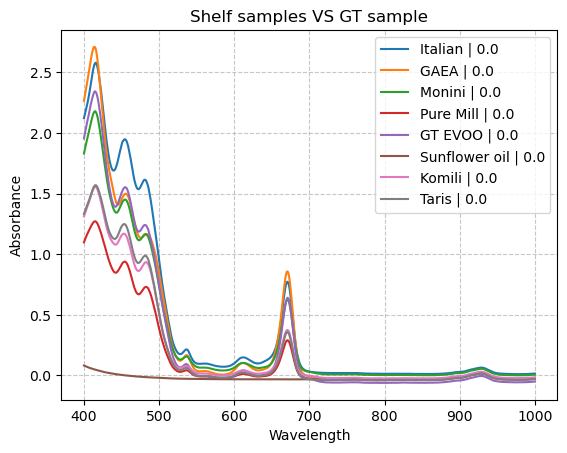

In [ ]:
dilutions = ['0']
samples = [ '11', '8', '1', 'the_mill_100', '3', '4', '9', '10']
get_common_graph_diverse(samples, dilutions, 'Shelf samples VS GT sample')

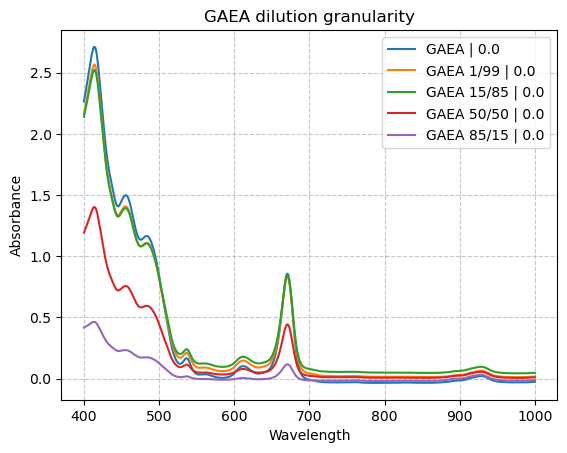

In [50]:
dilutions = ['0']
samples = [ '8', 'gaea_1_99', 'gaea_15_85', 'gaea_50_50', 'gaea_85_15']
get_common_graph_diverse(samples, dilutions, 'GAEA dilution granularity')


0.0012472191289246482